# Income Prediction — Logistic Regression Classifier
### Dataset: UCI Adult / Census Income Dataset

---

This notebook builds a complete machine learning pipeline to predict whether a person earns **more or less than $50,000 per year** based on demographic and employment data.

**Workflow:**
1. Import libraries
2. Load and explore the dataset
3. Handle missing values
4. Encode categorical features
5. Define features and target
6. Normalise features
7. Split into train and test sets
8. Fit the Logistic Regression model
9. Evaluate with accuracy, confusion matrix, precision, recall, F1, and ROC-AUC

---

## Step 1 — Import Libraries

We load all the libraries needed for this notebook upfront:

| Library | Purpose |
|---|---|
| `pandas` | Load and manipulate tabular data |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Data visualisation |
| `sklearn.model_selection` | Train/test splitting |
| `sklearn.linear_model` | Logistic Regression model |
| `sklearn.preprocessing` | Label encoding and feature scaling |
| `sklearn.metrics` | Accuracy, confusion matrix, precision, recall, F1, ROC-AUC |

`warnings.filterwarnings("ignore")` suppresses non-critical warnings to keep the output clean.

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


## Step 2 — Load and Explore the Dataset

We read the CSV file into a **pandas DataFrame** — think of it as a spreadsheet in Python.

> **Note on this file's format:** Each row is wrapped in double-quotes with comma-separated values inside. We strip those outer quotes before parsing so pandas reads it correctly.

`df.head()` shows the first 5 rows so we can confirm the data loaded correctly and get a feel for the columns.

In [5]:
# Reading dataset
# The CSV wraps each row in double-quotes — strip them before parsing
with open("income_prediction.csv") as f:
    lines = f.read().splitlines()

clean_lines = [line.strip('"') for line in lines]
df = pd.read_csv(io.StringIO("\n".join(clean_lines)), skipinitialspace=True)
df.columns = df.columns.str.strip()
df.head()


,Age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Dataset Dimensions

`df.shape` returns a tuple of **(rows, columns)**. This tells us how large the dataset is before we do anything to it.

In [7]:
df.shape


(32561, 15)

### Summary Statistics

`df.describe()` computes key statistics for every numeric column — count, mean, standard deviation, min, max, and quartiles.

This is important for spotting:
- Columns with very wide ranges (which will need scaling later)
- Unusually high max values that might be outliers

In [9]:
df.describe()


,Age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Missing Value Check

`df.isna().sum()` counts the number of `NaN` (missing) values in each column.

In this dataset, missing values are encoded as `?` rather than `NaN`. We will handle that in the cleaning step. This check confirms whether pandas has already detected any nulls.

In [11]:
df.isna().sum()


Age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
label             0
dtype: int64

### Data Types

`df.dtypes` shows the data type of each column — integer, float, or object (text).

This is important because machine learning models only accept **numeric** inputs. Any column showing `object` must be encoded into numbers before training.

In [13]:
df.dtypes


Age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
label             object
dtype: object

### Target Variable — Unique Classes

We check the unique values in our target column `label` to confirm it is a **binary classification** problem.

We expect two classes: `<=50K` and `>50K`.

In [15]:
df['label'].unique()


array(['<=50K', '>50K'], dtype=object)

## Step 3 — Exploratory Data Analysis (EDA)

Before modelling, we visualise the data to understand its distribution and spot any imbalances.

### Class Distribution

A bar chart of the `label` column shows how many people fall into each income group. If one class is much larger than the other, we have a **class imbalance** — and the model will tend to favour the majority class. Understanding this upfront helps us interpret the results later.

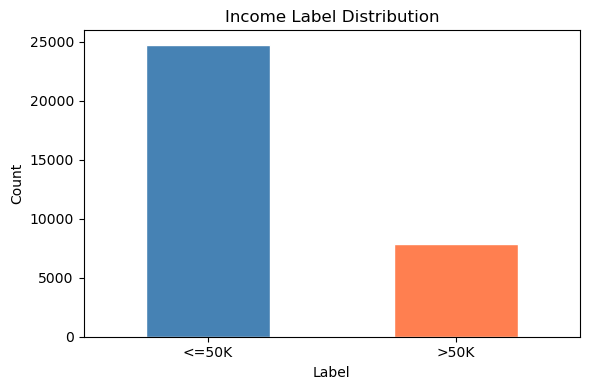

In [17]:
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue','coral'], edgecolor='white')
plt.title('Income Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Feature Distributions

Histograms of the key numeric columns — `Age`, `education-num`, `hours-per-week`, `capital-gain`, and `capital-loss` — reveal the shape of each feature's distribution.

Things to look for:
- **Skewed distributions** (most values are small but a few are very large, like `capital-gain`)
- **Roughly normal distributions** (bell-shaped, like `Age`)

Heavily skewed features with different scales are exactly why we apply `StandardScaler` later.

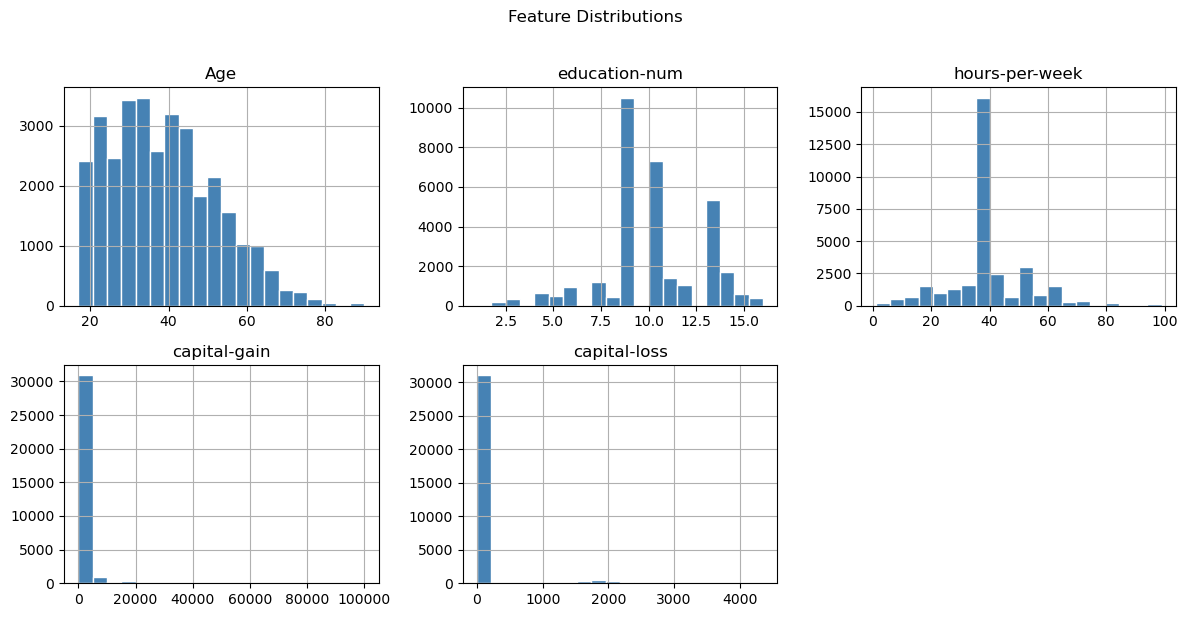

In [19]:
df[['Age','education-num','hours-per-week','capital-gain','capital-loss']].hist(
    bins=20, figsize=(12,6), layout=(2,3), color='steelblue', edgecolor='white'
)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()


## Step 4 — Handle Missing Values

This dataset uses `?` as a placeholder for unknown values rather than leaving the cell blank.

We:
1. Replace every `?` with `NaN` so pandas recognises them as missing
2. Drop all rows containing `NaN` — a simple strategy appropriate here since the affected rows are a small fraction of the full dataset

`df.shape` after dropping shows how many rows remain.

In [21]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df.shape


(30162, 15)

## Step 5 — Encode Categorical Features

Machine learning models cannot work with text — every column must be numeric.

**Label Encoding** converts each unique text value in a column to an integer. For example:
- `workclass`: `Private` → 3, `Self-emp-not-inc` → 5, etc.
- `sex`: `Male` → 1, `Female` → 0

We loop through every column with data type `object` and apply `LabelEncoder` to it.

`df.head()` confirms all columns now contain numbers.

In [23]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))
df.head()


,Age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0


## Step 6 — Define Features and Target Variable

We split the DataFrame into two parts:

- **`features`** — all columns except `label`. These are the inputs the model learns from (age, education, occupation, etc.)
- **`target`** — the `label` column only. This is what the model predicts: `0` for `<=50K` and `1` for `>50K`

This separation is a required step before any further processing.

In [25]:
features = df.drop('label', axis=1)
target = df['label']


## Step 7 — Normalise Features (StandardScaler)

Our feature columns have very different numeric ranges:
- `fnlwgt` can be in the hundreds of thousands
- `sex` is just 0 or 1

Logistic Regression's solver (`lbfgs`) must take tiny, careful steps when features are on wildly different scales — and it can run out of iterations before converging. This produces the **ConvergenceWarning**.

`StandardScaler` fixes this by transforming every feature to have **mean = 0** and **standard deviation = 1**, putting them all on the same scale so the solver converges quickly.

> **Important rule:** We call `fit_transform()` on the training data and `transform()` only on the test data. Fitting the scaler on the test set would leak information about unseen data into the model.

In [27]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


## Step 8 — Split into Train and Test Sets

We divide the dataset into two non-overlapping subsets:

- **Training set (80%)** — the model learns from this data
- **Test set (20%)** — held back and never seen during training; used only for final evaluation

This simulates how the model would perform on completely new, real-world data.

`random_state=42` ensures the split is reproducible — every run produces the same result.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.2, random_state=42
)


Confirming the sizes of the training and test sets.

In [31]:
print(X_train.shape, X_test.shape)


(24129, 14) (6033, 14)


## Step 9 — Fit the Logistic Regression Model

**Logistic Regression** is a classification algorithm that predicts the *probability* a sample belongs to a given class.

Despite the name, it predicts **categories** (not continuous numbers). It works by:
1. Computing a weighted sum of the input features
2. Passing that sum through a **sigmoid function** to produce a probability between 0 and 1
3. Predicting `>50K` if the probability exceeds 0.5, otherwise `<=50K`

`model.fit(X_train, y_train)` trains the model — it adjusts the feature weights until predictions on the training set are as accurate as possible.

Model Fitting

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

### Feature Weights (Coefficients)

After training, each feature has a learned **weight (coefficient)**.

- A **positive** coefficient means that feature pushes the prediction toward `>50K`
- A **negative** coefficient means it pushes toward `<=50K`
- Larger absolute values indicate greater influence on the prediction

In [36]:
weight_df = pd.DataFrame({
    'features': df.drop('label', axis=1).columns,
    'weights': model.coef_.tolist()[0]
})
weight_df


,features,weights
0,Age,0.487459
1,workclass,-0.112970
2,fnlwgt,0.063323
3,education,0.055500
4,education-num,0.844699
5,marital-status,-0.335875
6,occupation,0.002781
7,relationship,-0.201662
8,race,0.097631
9,sex,0.422758


## Step 10 — Predictions on the Training Set

We first check how well the model performs on the data it was trained on.

If training accuracy is much higher than test accuracy (Step 11), it suggests the model is **overfitting** — memorising the training data rather than learning general patterns.

Making predictions on the training set

In [39]:
pred_train = model.predict(X_train)


In [40]:
acc_train = accuracy_score(y_train, pred_train)
print(f"Accuracy on training set: {acc_train:.4f}")


Accuracy on training set: 0.8198


`model.predict_proba()` returns the probability of each class for every sample — two columns, one per class. The second column (`[:, 1]`) is the probability of predicting `>50K`.

In [42]:
model.predict_proba(X_train)


array([[0.86048609, 0.13951391],
       [0.34095776, 0.65904224],
       [0.87438553, 0.12561447],
       ...,
       [0.48941041, 0.51058959],
       [0.97246519, 0.02753481],
       [0.5122947 , 0.4877053 ]])

`model.classes_` confirms the order of classes the model learned — `[0, 1]` corresponding to `<=50K` and `>50K`.

In [44]:
model.classes_


array([0, 1])

## Step 11 — Predictions on the Test Set

Now we evaluate the model on the **held-out test set** — data it has never seen.

- `pred_test` — the hard class predictions (`0` or `1`)
- `y_probs` — the predicted probability of `>50K` for each test sample (needed for the ROC curve)

Making predictions on the test set

In [47]:
pred_test = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]


**Test accuracy** is the primary metric. It measures the percentage of test samples the model classified correctly.

Comparing this with training accuracy tells us whether the model generalises well.

In [49]:
acc_test = accuracy_score(y_test, pred_test)
print(f"Accuracy on test set: {acc_test:.4f}")


Accuracy on test set: 0.8231


## Step 12 — Confusion Matrix

A confusion matrix breaks down predictions into four categories:

| | Predicted <=50K | Predicted >50K |
|---|---|---|
| **Actual <=50K** | True Negative (TN) | False Positive (FP) |
| **Actual >50K** | False Negative (FN) | True Positive (TP) |

- **True Negatives / True Positives** → correct predictions
- **False Positives** → predicted `>50K` but was actually `<=50K`
- **False Negatives** → predicted `<=50K` but was actually `>50K` (the costlier mistake in income prediction)

The heatmap makes the pattern immediately visible — darker cells on the diagonal mean more correct predictions.

Confusion Matrix

In [52]:
mat = confusion_matrix(y_test, pred_test)


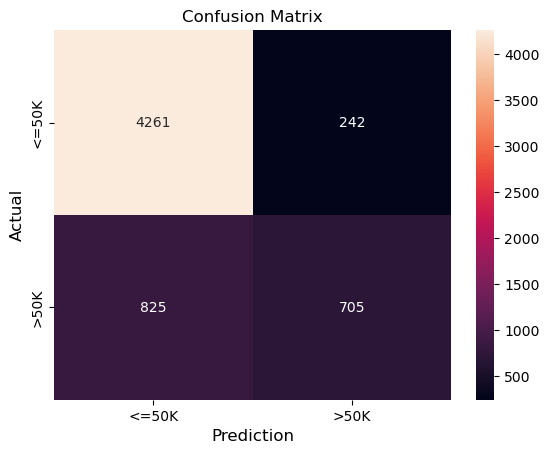

In [53]:
sns.heatmap(mat,
            annot=True,
            fmt='g',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])

plt.ylabel('Actual', fontsize=12)
plt.xlabel('Prediction', fontsize=12)
plt.title('Confusion Matrix')
plt.show()


## Step 13 — Precision Score

**Precision** answers: *Of all the people the model predicted as `>50K`, how many actually were?*

A high precision means the model rarely raises a false alarm — when it says `>50K`, it is usually right.

$$\text{Precision score} = \frac{TP}{TP + FP}$$

In [55]:
precision_score(y_test, pred_test)


0.7444561774023232

## Step 14 — Recall Score

**Recall** answers: *Of all people who actually earn `>50K`, how many did the model correctly identify?*

A high recall means the model misses very few of the true `>50K` earners. Low recall means many `>50K` earners are being misclassified as `<=50K`.

$$\text{Recall score} = \frac{TP}{TP + FN}$$

In [57]:
recall_score(y_test, pred_test)


0.46078431372549017

## Step 15 — F1 Score

**F1** is the harmonic mean of Precision and Recall. It is the go-to metric when you need a single number that balances both.

It is especially useful here because we have a **class imbalance** — far more `<=50K` samples than `>50K`. Accuracy alone would be misleading; F1 accounts for how well the model handles both classes.

$$\text{F1-Score} = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [59]:
f1_score(y_test, pred_test)


0.5692369802180056

## Step 16 — ROC Curve and AUC Score

The **ROC (Receiver Operating Characteristic) curve** plots the trade-off between:
- **True Positive Rate (Recall)** — how many actual `>50K` earners we catch
- **False Positive Rate** — how many `<=50K` earners we wrongly flag as `>50K`

$$\text{False Positive Rate (FPR)} = \frac{FP}{TN + FP}$$

**AUC (Area Under the Curve)** summarises the curve as a single number between 0 and 1:
- **AUC = 1.0** → perfect classifier
- **AUC = 0.5** → no better than random guessing (the red dashed line)
- **AUC > 0.85** → strong performance

A curve that hugs the top-left corner of the plot is a strong model.

In [61]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
print("AUC:", auc_score)


AUC: 0.8597735133730744


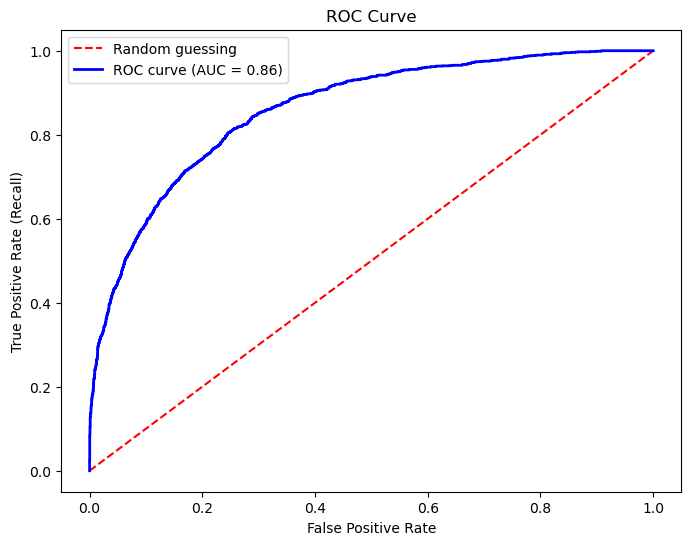

In [62]:
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random guessing')
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Summary

| Step | Action | Why |
|---|---|---|
| 1 | Import libraries | Load all tools needed for the pipeline |
| 2 | Load & explore data | Understand shape, types, and distributions |
| 3 | EDA | Visualise class balance and feature distributions |
| 4 | Handle missing values | Replace `?` with NaN and drop incomplete rows |
| 5 | Encode categories | Convert text columns to integers |
| 6 | Define X and y | Separate inputs from the target variable |
| 7 | Scale features | Bring all features to the same range; fixes ConvergenceWarning |
| 8 | Train/test split | Hold out 20% of data for unbiased evaluation |
| 9 | Fit model | Train Logistic Regression on scaled training data |
| 10 | Train evaluation | Check for overfitting by comparing with test accuracy |
| 11 | Test evaluation | Measure real-world performance on unseen data |
| 12 | Confusion matrix | See exactly where the model is right and wrong |
| 13 | Precision | Quality of positive predictions |
| 14 | Recall | Coverage of actual positive cases |
| 15 | F1 Score | Balance of precision and recall |
| 16 | ROC-AUC | Overall discriminative power of the model |

---
*Built with scikit-learn, pandas, matplotlib, and seaborn.*